## Perturbation experiments for ITER with TokaMaker_TORAX: Vertical Stability

2026-09-28 D. Fisher

This notebook first sets up an example pulse simulation using a TokaMaker and TORAX coupled workflow. The inputs are based on Budney et al. 2008 Nuclear Fusion, but are not intended to be exact or in any way an ideal ITER shot.

After establishing a standard pulse, we will apply a perturbation and analyze what effect this has on the pulse.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from OpenFUSIONToolkit.TokaMaker.pulse_design import compute_disruptivity_limits, plot_ldl_hdl_with_mode, plot_dl_combined_single_color
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [2]:
# Global inputs
R0 = 6.3 # m, geometric center of the device
B0 = 5.2 # T, toroidal magnetic field at center of the device
Z0 = 0.5 # m, center of ITER plasma is at +0.5 m on this grid

In [3]:
# OFT setup
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.pulse_design import TokaMaker_TORAX
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_power_flux_fun, create_isoflux
import numpy as np
import matplotlib.pyplot as plt
import os
cwd = os.getcwd()

myOFT = OFT_env(nthreads=4)
mygs = TokaMaker(myOFT)

mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('ITER_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.settings.maxits=100
mygs.setup(order = 2, F0 = R0*B0)

mygs.set_coil_vsc({'VS': 1.0})

# Silence CG Solver
mygs.settings.pm = False
mygs.update_settings()

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Base release:        
Development branch:  disruptivity-limits
Revision id:         6eabd40

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    4

Linear Algebra backend: native

#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  2.859E+02
    # of points  =    4757
    # of edges   =   14156
    # of cells   =    9400
    # of boundary points =     112
    # of boundary edges  =     112
    # of boundary cells  =     112
  Resolution statistics:
    hmin =  9.924E-03
    hrms =  2.826E-01
    hmax =  8.466E-01
  Surface grounded at vertex     870


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux 

In [4]:
# Set coil bounds
coil_bounds = {key: [-50.E6, 50.E6] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

# function to build regularization terms for coil currents for initial equilibrium solves.
def build_min_norm_coil_reg(mygs):
    """Mild regularization to keep currents reasonable without targeting specific coils."""
    reg_terms = []
    for name in mygs.coil_sets:
        if name.startswith('CS'):
            weight = 2.E-2 if name.startswith('CS1') else 1.E-2
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=weight))
        elif name.startswith('PF'):
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.E-2))
        elif name.startswith('VS'):
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.E-2))
    reg_terms.append(mygs.coil_reg_term({'#VSC': 1.0}, target=0.0, weight=1.E2))
    mygs.set_coil_reg(reg_terms=reg_terms)

In [5]:
# Make initial FF' and p' profiles for initial equilibria
ffp_prof = create_power_flux_fun(40,1.5,2.0)
pp_prof = create_power_flux_fun(40,4.0,1.0)
mygs.set_profiles(ffp_prof=ffp_prof,pp_prof=pp_prof)

In [6]:
# Make Ip and pax targets
Ip_targets = [1.5e6, 5e6, 15e6, 15e6, 1.5e6]
# pax = pressure on axis
# pax targets calculated from Budney et al. 2008 plots
pax_initial = 2 * 1e19 * 1e3 * 1.602e-19
pax_final = 2 * 1e20 * 12.5e3 * 1.603e-19
pax_targets = [pax_initial, 0.3*pax_initial, pax_final, pax_final, pax_initial]

In [7]:
# Set shape targets
a = [1, 2, 2, 2, 1]
kappa = [1, 1.3, 1.8, 1.8, 1]
delta = [0, 0, 0, 0, 0]
diverted = [False, False, True, True, False]
x_points = np.array([[5.125, -3.4],])
diverted_isoflux_pts =np.array([
    [ 8.20,  0.41],
    [ 8.06,  1.46],
    [ 7.51,  2.62],
    [ 6.14,  3.78],
    [ 5.1 ,  3.72],
    [ 4.51,  3.02],
    [ 4.26,  1.33],
    [ 4.28,  0.08],
    [ 4.49, -1.34],
    [ 7.28, -1.89],
    [ 8.00, -0.68]
])
target_psi_lcfs = [+20, +13, +10, 0, +5] # Wb/rad targets for LCFS flux. Only the first value is used by TORAX, the others are overwritten after the first TORAX run.

In [8]:
# Produce initial equilibria
psi_lcfs_results = []

for idx in range(len(a)):
    psi_lcfs_target = target_psi_lcfs[idx]

    if diverted[idx]:  # Flattop (mid-swing)
        R = R0
        mygs.set_saddle_constraints(x_points)
        mygs.set_isoflux_constraints(diverted_isoflux_pts)
        psi_lcfs_weight = 10
        targets = np.full(diverted_isoflux_pts.shape[0], psi_lcfs_target)
        weights = np.full(diverted_isoflux_pts.shape[0], psi_lcfs_weight)
        mygs.set_flux(diverted_isoflux_pts, targets, weights=weights)
    else:  # Ramp-up/down (pre-charged)
        R = 3.9 + a[idx]
        isoflux_pts = create_isoflux(20, R, Z0, a[idx], kappa[idx], delta[idx])
        mygs.set_isoflux_constraints(isoflux_pts)
        # set_flux_target_on_lcfs(mygs, isoflux_pts, psi_lcfs_target, weight=5.0)
        # build_coil_reg(mygs, cs_precharge_targets) # sets coil targets and regularization depending on phase
        psi_lcfs_weight = 10
        targets = np.full(isoflux_pts.shape[0], psi_lcfs_target)
        weights = np.full(isoflux_pts.shape[0], psi_lcfs_weight)
        mygs.set_flux(isoflux_pts, targets, weights=weights)

    build_min_norm_coil_reg(mygs)
    mygs.set_targets(Ip=Ip_targets[idx], pax=pax_targets[idx])

    mygs.init_psi(R, Z0, a[idx], kappa[idx], delta[idx])
    equil_object = mygs.solve()

    stats = mygs.get_stats()
    psi_lcfs = mygs.psi_bounds[0]
    psi_lcfs_results.append(psi_lcfs)
    coil_currents, _ = mygs.get_coil_currents()

    eqdsk_name = os.path.join(cwd, f'i={idx}.eqdsk')
    mygs.save_eqdsk(eqdsk_name, cocos=2, nr=500, nz=500) # saving at extremely high resolution to avoid issues with contour tracing package used by TORAX, only necessary for initial eqdkss, could possibly be lowered

/var/folders/0c/497qwkps0n92lm8mgp_t18800000gn/T/ipykernel_62015/4242415327.py:24: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(isoflux_pts, targets, weights=weights)


Saving gEQDSK: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/i=0.eqdsk
 Using COCOS=2...
Saving gEQDSK: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/i=1.eqdsk
 Using COCOS=2...


/var/folders/0c/497qwkps0n92lm8mgp_t18800000gn/T/ipykernel_62015/4242415327.py:14: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(diverted_isoflux_pts, targets, weights=weights)


Saving gEQDSK: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/i=2.eqdsk
 Using COCOS=2...
Saving gEQDSK: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/i=3.eqdsk
 Using COCOS=2...
Saving gEQDSK: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/i=4.eqdsk
 Using COCOS=2...


In [9]:

eqdsk_list = [os.path.join(cwd, 'i=0.eqdsk'),  # use initial eqdsk to start
              os.path.join(cwd, 'i=1.eqdsk'),  
              os.path.join(cwd, 'i=2.eqdsk'),  # start of flattop
              os.path.join(cwd, 'i=3.eqdsk'),  # end of flattop
              os.path.join(cwd, 'i=4.eqdsk')]  # use initial eqdsk as end of pulse

eqtimes = [0, 30, 80, 500, 600] # times corresponding to each initial eqdsk


t_final = 600
tmtx = TokaMaker_TORAX(
    t_init = 0,
    t_final = t_final,
    tx_dt = 1, # s, TORAX time step 
    eqtimes = eqtimes,
    g_eqdsk_arr = eqdsk_list,
    last_surface_factor = 0.99,
    tm_times = np.linspace(0, t_final, 25), # the times at which TokaMaker will solve equilibria
    tokamaker_obj = mygs, # passes existing OFT environment to TokaMaker_TORAX
)

In [10]:
# Set TORAX Grid, 51 points evenly spaced in rho_toroidal space (TORAX radial coordinate).
tmtx.set_TORAX_grid(grid_type='n_rho', grid=51)

In [11]:
# Heating (Budney 2008 NF: ~33 MW NBI + ~20 MW ECRH at flattop = ~53 MW total)
# ECRH-assisted startup: ECRH on early in current ramp to raise Te, reduce Vloop.

# ECRH: on during ramp-up for assisted startup, continues through flattop and partway into rampdown
ecrh_powers = {
    0:    0,
    10:   0,
    50:   20.0E6,    # ECRH-assisted startup (Budney 2008: ~20 MW during ramp-up)
    80:   20.0E6,    # L-H transition; ECRH stays at 20 MW
    450:  20.0E6,    # End of flattop
    500:  15.0E6,    # Start rampdown
    520:  10.0E6,
    540:  5.0E6,
    560:  0,
    600:  0,
}

# NBI: turns on at L-H transition when plasma is sufficiently dense (Budney 2008: ~33 MW)
generic_powers = {
    0:    0,
    79:   0,
    80:   33.0E6,    # NBI on at L-H transition
    450:  33.0E6,    # End of flattop
    500:  15.0E6,    # Start rampdown
    520:  10.0E6,
    540:  7.0E6,
    560:  4.0E6,
    580:  2.0E6,
    600:  0,
}
tmtx.set_heating(generic_heat=generic_powers, generic_heat_loc=0.25, nbi_current=True, ecrh=ecrh_powers, ecrh_loc=0.35)

tmtx.set_fueling(gas_puff_S_total=1e22, gas_puff_decay_length=0.05, pellet_deposition_location=0.8, pellet_width=0.1, pellet_S_total={0: 0, 90: 5e21, 450: 5e21, 451: 0}) # estimations based on budney2008

In [12]:
# Build initial kinetic profiles
n_sample = 25
psi_sample = np.linspace(0.0, 1.0, n_sample)

def array_to_profile_dict(profile_array, psi_grid=None):
    """Convert 1D profile array to TORAX format {psi: value}"""
    if psi_grid is None:
        psi_grid = np.linspace(0.0, 1.0, len(profile_array))
    return {float(psi): float(val) for psi, val in zip(psi_grid, profile_array)}

# Initial L-mode profiles at t=0, will be relaxed during initial relax loop
ne_init = np.array([3.00000000e+19, 2.72795206e+19, 2.48786856e+19, 2.27599203e+19,
       2.08902740e+19, 1.92402147e+19, 1.77840567e+19, 1.64989820e+19,
       1.53648493e+19, 1.43640818e+19, 1.34808146e+19, 1.27014059e+19,
       1.20134100e+19, 1.14064701e+19, 1.08707306e+19, 1.03979586e+19,
       9.98080158e+18, 9.61263085e+18, 9.28769440e+18, 9.00095433e+18,
       8.74788171e+18, 8.52450318e+18, 8.32749199e+18, 8.15354792e+18,
       8.00000000e+18])
Te_init = np.array([1.5       , 1.32687858, 1.17409817, 1.03926765, 0.92029017,
       0.81528639, 0.72262179, 0.64084431, 0.56867223, 0.50498703,
       0.44877911, 0.39918038, 0.35539882, 0.31677537, 0.28268285,
       0.25259736, 0.22605101, 0.20262196, 0.18194419, 0.16369709,
       0.14759247, 0.13337748, 0.1208404 , 0.10977123, 0.1       ])

# Initial profiles only (t=0); evolve=True so TORAX handles time evolution
ne = {0.0: array_to_profile_dict(ne_init, psi_sample)}
Te = {0.0: array_to_profile_dict(Te_init, psi_sample)}

# Initial kinetic profiles and edge boundary conditions
tmtx.set_ne(ne, right_bc={0: ne_init[-1], 80: 2e19, 500: 2e19, 600: .5e19})
tmtx.set_Te(Te, right_bc=0.1)
tmtx.set_Ti(Te, right_bc=0.1)

# Pedestal: H-mode pedestal-top targets. TORAX's L/H formation model decides when they are
# applied (P_SOL > P_LH) and removed (P_SOL < 0.8*P_LH), ramping over transition_time.
ne_ped_val = .9e20   # m^-3
Te_ped_val = 3.0     # keV, used for both Te and Ti

tmtx.set_pedestal(config_mode='ADAPTIVE_SOURCE',
                  ped_height_Te=Te_ped_val,
                  ped_height_Ti=Te_ped_val,
                  ped_height_ne=ne_ped_val,
                  ped_top=0.9,                     # rho_tor of the pedestal top
                  transition_time=10.0,            # s, L->H and H->L ramp duration
                  formation_model='martin_scaling')

In [13]:
# Misc final setup

tmtx.set_Ip({0: Ip_targets[0], 100: Ip_targets[2], 500: Ip_targets[2], 600: Ip_targets[0]})

# Plasma composition (DT fuel + Ne impurity; Zeff=1.6 sets Ne density)
tmtx.set_plasma_composition(main_ion={'D': 0.5, 'T': 0.5}, impurity='Ne', Zeff=1.6)

tmtx.set_evolve(density=True, Ti=True, Te=True, current=True)

# Diverted window: X-point target(s), and (optionally) a shape_target that overrides the
# seed-eqdsk LCFS shape targets while diverted. Here shape_target is omitted, so the shape
# is pulled from the seed equilibria as usual.
tmtx.set_diverted_shape_targets(diverted_times = (80, 500), x_point_targets = x_points, x_point_weight=100)

tmtx.set_TokaMaker_coil_reg(coil_bounds=coil_bounds, updownsym=False)

In [14]:
tmtx.fly(run_name='tmp', 
         output_mode='false', 
         max_loop=2,
         t_ave_toggle='flattop',
         t_ave_window=25,
         relax=True,
         relax_duration=5)

  Log file: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/TokaMaker_TORAX_log_tmp.log

 TokaMaker_TORAX  
 run_name = tmp | t=[0.0, 600.0] s | 25 timepoints | dt=1 s | max_loop=2

  Initial TORAX relax


Simulating (t=5.00000): 100%|██████████| 100/100 [00:06<00:00, 16.57it/s]



  Loop 1
  TORAX: running simulation...


Simulating (t=600.00000): 100%|██████████| 100/100 [00:32<00:00,  3.05it/s]


  TORAX: L->H transition at 81.44 s, H->L back-transition at 488.1 s
  TORAX: done (cflux=168.5975 Wb)
  TokaMaker: solving 25 equilibria...


...

  TORAX: running simulation...


Simulating (t=600.00000): 100%|██████████| 100/100 [00:31<00:00,  3.15it/s]


  TORAX: L->H transition at 80.67 s, H->L back-transition at 490 s
  TORAX: done (cflux=161.6995 Wb)
  TokaMaker: solving 25 equilibria...


  TM loop 2: 100%|██████████| 25/25 [01:26<00:00,  3.47s/solve], t=600.00s OK(L0)


  TokaMaker: 25/25 solved (cflux=161.7078 Wb)
	TM summary: 25/25 solved at tol: 1.00e-06. Levels: jphi_conv0.00: 23, jphi_conv0.50: 1, lv00_raw_torax_profiles: 1.
  Loop 2 result: conv_err=4.091% | TX-TM diff=0.0051% | cflux_TX=161.6995 Wb | cflux_TM=161.7078 Wb

  Max loop index (2) reached (err=4.091%)

  Loop   cflux TX [Wb]    cflux TM [Wb]    TX-TM diff %  
  ----------------------------------------------------
  1      168.5975         168.5973         0.0001        
  2      161.6995         161.7078         0.0051        

  End-of-flattop summary  (t = 500.00 s; flattop window [100.00, 500.00] s)
  --------------------------------------------------------
  Parameter                End-of-flattop      Flattop avg
  Fusion energy gained        76302.79 MJ                —
  Flux consumed                161.699 Wb                —
  P_fusion                        7.33 MW           186.74
  P_alpha                         1.47 MW            37.35
  Q                              

## Experiment: Vertical Stability

### 1. Direct evaluation of the Tobin metric

`plot_disruptivity_limits` builds its vertical-stability profile by calling `compute_vertical_stability_margin()` once per pulse timepoint. The same call works directly on any single solved equilibrium snapshot, which can be useful on its own for spot-checking one point in the pulse as shown below.

In [15]:
# Evaluate -F_z' directly for one equilibrium snapshot, mid-flattop
i_check = int(np.argmin(np.abs(np.array(tmtx._tm_times) - 250.0)))
t_check = tmtx._tm_times[i_check]
neg_Fz_prime = tmtx.state['equil'][i_check].compute_vertical_stability_margin()
print(f"-F_z' at t={t_check:.0f} s (i={i_check}) = {neg_Fz_prime:.3e} N/m")

-F_z' at t=250 s (i=10) = 4.518e+07 N/m


A positive value means the plasma is vertically stable at that instant. This is the same `-F'_z` quantity plotted continuously in the vertical-stability example below, just queried at one point rather than the whole pulse.

### 2. Elongation and vertical stability

We override the LCFS shape target for the diverted window (t=80-500s) with a less elongated shape, scaling the target points' vertical extent down by 20%.

Physically, less elongated plasmas tend to be more stable to vertical displacement, as the vertical-field decay index a plasma can tolerate before going unstable widens as kappa decreases. In the Tobin equation, this shows up as the plasma current distribution and its coupling to the passive structure and coils reshaping in a way that increases the restoring term, pushing `-F'_z` away from zero.


In [16]:
# Re-solve seed equilibrium i=1 with decreased elongation
kappa_scale = 0.8
shape_target = diverted_isoflux_pts.copy()
shape_target[:, 1] = Z0 + kappa_scale * (shape_target[:, 1] - Z0)
x_points_pert = x_points.copy()
x_points_pert[:, 1] = Z0 + kappa_scale * (x_points[:, 1] - Z0)

tmtx_kappa = TokaMaker_TORAX(
    t_init=0, t_final=t_final, tx_dt=1, eqtimes=eqtimes, g_eqdsk_arr=eqdsk_list,
    last_surface_factor=0.99, tm_times=np.linspace(0, t_final, 25), tokamaker_obj=mygs,
)
tmtx_kappa.set_TORAX_grid(grid_type='n_rho', grid=51)
tmtx_kappa.set_heating(generic_heat=generic_powers, generic_heat_loc=0.25, nbi_current=True, ecrh=ecrh_powers, ecrh_loc=0.35)
tmtx_kappa.set_fueling(gas_puff_S_total=1e22, gas_puff_decay_length=0.05, pellet_deposition_location=0.8, pellet_width=0.1, pellet_S_total={0: 0, 90: 5e21, 450: 5e21, 451: 0})
tmtx_kappa.set_ne(ne, right_bc={0: ne_init[-1], 80: 2e19, 500: 2e19, 600: .5e19})
tmtx_kappa.set_Te(Te, right_bc=0.1)
tmtx_kappa.set_Ti(Te, right_bc=0.1)
tmtx_kappa.set_pedestal(config_mode='ADAPTIVE_SOURCE', ped_height_Te=Te_ped_val, ped_height_Ti=Te_ped_val,
                         ped_height_ne=ne_ped_val, ped_top=0.9, transition_time=10.0, formation_model='martin_scaling')
tmtx_kappa.set_Ip({0: Ip_targets[0], 100: Ip_targets[2], 500: Ip_targets[2], 600: Ip_targets[0]})
tmtx_kappa.set_plasma_composition(main_ion={'D': 0.5, 'T': 0.5}, impurity='Ne', Zeff=1.6)
tmtx_kappa.set_evolve(density=True, Ti=True, Te=True, current=True)
tmtx_kappa.set_diverted_shape_targets(diverted_times=(80, 500), x_point_targets=x_points_pert, x_point_weight=100,
                                       shape_target=shape_target)
tmtx_kappa.set_TokaMaker_coil_reg(coil_bounds=coil_bounds, updownsym=False)

tmtx_kappa.fly(run_name='tmp', output_mode='false', max_loop=2, t_ave_toggle='flattop',
               t_ave_window=25, relax=True, relax_duration=5)

  Log file: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/TokaMaker_TORAX_log_tmp.log

 TokaMaker_TORAX  
 run_name = tmp | t=[0.0, 600.0] s | 25 timepoints | dt=1 s | max_loop=2

  Initial TORAX relax


Simulating (t=5.00000): 100%|██████████| 100/100 [00:00<00:00, 143.49it/s]



  Loop 1
  TORAX: running simulation...


Simulating (t=600.00000): 100%|██████████| 100/100 [00:20<00:00,  4.87it/s]


  TORAX: L->H transition at 81.44 s, H->L back-transition at 488.1 s
  TORAX: done (cflux=168.5975 Wb)
  TokaMaker: solving 25 equilibria...


...

  TORAX: running simulation...


Simulating (t=600.00000): 100%|██████████| 100/100 [00:24<00:00,  4.12it/s]


  TORAX: L->H transition at 80.67 s, H->L back-transition at 498.3 s
  TORAX: done (cflux=245.9022 Wb)
  TokaMaker: solving 25 equilibria...


  TM loop 2: 100%|██████████| 25/25 [01:13<00:00,  2.95s/solve], t=600.00s OK(L0)


  TokaMaker: 25/25 solved (cflux=245.9078 Wb)
	TM summary: 25/25 solved at tol: 1.00e-06. Levels: jphi_conv0.00: 24, jphi_conv0.50: 1.
  Loop 2 result: conv_err=45.852% | TX-TM diff=0.0023% | cflux_TX=245.9022 Wb | cflux_TM=245.9078 Wb

  Max loop index (2) reached (err=45.852%)

  Loop   cflux TX [Wb]    cflux TM [Wb]    TX-TM diff %  
  ----------------------------------------------------
  1      168.5975         168.5973         0.0001        
  2      245.9022         245.9078         0.0023        

  End-of-flattop summary  (t = 500.00 s; flattop window [100.00, 500.00] s)
  --------------------------------------------------------
  Parameter                End-of-flattop      Flattop avg
  Fusion energy gained        32436.93 MJ                —
  Flux consumed                245.902 Wb                —
  P_fusion                       14.69 MW            78.23
  P_alpha                         2.94 MW            15.65
  Q                                 0.403            1.398


As evident in the full disruptivity limits plot, F'_z is erratic for the current elongation. This is because the the fully elongated pulse's plasma boundary passes close enough to a couple of the active coils that the vertical stability metric picks up sharp local sensitivity. To provide a more clear picture for comparison, we reduce the elongation of the baseline pulse as well, but by 10% rather than 20% of the original.

In [17]:
kappa_scale = 0.9
shape_target = diverted_isoflux_pts.copy()
shape_target[:, 1] = Z0 + kappa_scale * (shape_target[:, 1] - Z0)
x_points_pert = x_points.copy()
x_points_pert[:, 1] = Z0 + kappa_scale * (x_points[:, 1] - Z0)

tmtx = TokaMaker_TORAX(
    t_init=0, t_final=t_final, tx_dt=1, eqtimes=eqtimes, g_eqdsk_arr=eqdsk_list,
    last_surface_factor=0.99, tm_times=np.linspace(0, t_final, 25), tokamaker_obj=mygs,
)
tmtx.set_TORAX_grid(grid_type='n_rho', grid=51)
tmtx.set_heating(generic_heat=generic_powers, generic_heat_loc=0.25, nbi_current=True, ecrh=ecrh_powers, ecrh_loc=0.35)
tmtx.set_fueling(gas_puff_S_total=1e22, gas_puff_decay_length=0.05, pellet_deposition_location=0.8, pellet_width=0.1, pellet_S_total={0: 0, 90: 5e21, 450: 5e21, 451: 0})
tmtx.set_ne(ne, right_bc={0: ne_init[-1], 80: 2e19, 500: 2e19, 600: .5e19})
tmtx.set_Te(Te, right_bc=0.1)
tmtx.set_Ti(Te, right_bc=0.1)
tmtx.set_pedestal(config_mode='ADAPTIVE_SOURCE', ped_height_Te=Te_ped_val, ped_height_Ti=Te_ped_val,
                         ped_height_ne=ne_ped_val, ped_top=0.9, transition_time=10.0, formation_model='martin_scaling')
tmtx.set_Ip({0: Ip_targets[0], 100: Ip_targets[2], 500: Ip_targets[2], 600: Ip_targets[0]})
tmtx.set_plasma_composition(main_ion={'D': 0.5, 'T': 0.5}, impurity='Ne', Zeff=1.6)
tmtx.set_evolve(density=True, Ti=True, Te=True, current=True)
tmtx.set_diverted_shape_targets(diverted_times=(80, 500), x_point_targets=x_points_pert, x_point_weight=100,
                                       shape_target=shape_target)
tmtx.set_TokaMaker_coil_reg(coil_bounds=coil_bounds, updownsym=False)

tmtx.fly(run_name='tmp', output_mode='false', max_loop=2, t_ave_toggle='flattop',
               t_ave_window=25, relax=True, relax_duration=5)

  Log file: /Users/d22fish/Documents/7FusionResearch/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/Plasma_Limits/TokaMaker_TORAX_log_tmp.log

 TokaMaker_TORAX  
 run_name = tmp | t=[0.0, 600.0] s | 25 timepoints | dt=1 s | max_loop=2

  Initial TORAX relax


Simulating (t=5.00000): 100%|██████████| 100/100 [00:00<00:00, 113.68it/s]



  Loop 1
  TORAX: running simulation...


Simulating (t=600.00000): 100%|██████████| 100/100 [00:17<00:00,  5.59it/s]


  TORAX: L->H transition at 81.44 s, H->L back-transition at 488.1 s
  TORAX: done (cflux=168.5975 Wb)
  TokaMaker: solving 25 equilibria...


...

  TORAX: running simulation...


Simulating (t=600.00000): 100%|██████████| 100/100 [00:20<00:00,  4.84it/s]


  TORAX: L->H transition at 81 s, H->L back-transition at 483.7 s
  TORAX: done (cflux=192.7242 Wb)
  TokaMaker: solving 25 equilibria...


  TM loop 2: 100%|██████████| 25/25 [01:31<00:00,  3.65s/solve], t=600.00s OK(L0)


  TokaMaker: 25/25 solved (cflux=192.7325 Wb)
	TM summary: 25/25 solved at tol: 1.00e-06. Levels: jphi_conv0.00: 22, jphi_conv0.50: 3.
  Loop 2 result: conv_err=14.310% | TX-TM diff=0.0043% | cflux_TX=192.7242 Wb | cflux_TM=192.7325 Wb

  Max loop index (2) reached (err=14.310%)

  Loop   cflux TX [Wb]    cflux TM [Wb]    TX-TM diff %  
  ----------------------------------------------------
  1      168.5975         168.5972         0.0002        
  2      192.7242         192.7325         0.0043        

  End-of-flattop summary  (t = 500.00 s; flattop window [100.00, 500.00] s)
  --------------------------------------------------------
  Parameter                End-of-flattop      Flattop avg
  Fusion energy gained        52813.04 MJ                —
  Flux consumed                192.724 Wb                —
  P_fusion                        4.41 MW           128.78
  P_alpha                         0.88 MW            25.76
  Q                                 0.119            2.350


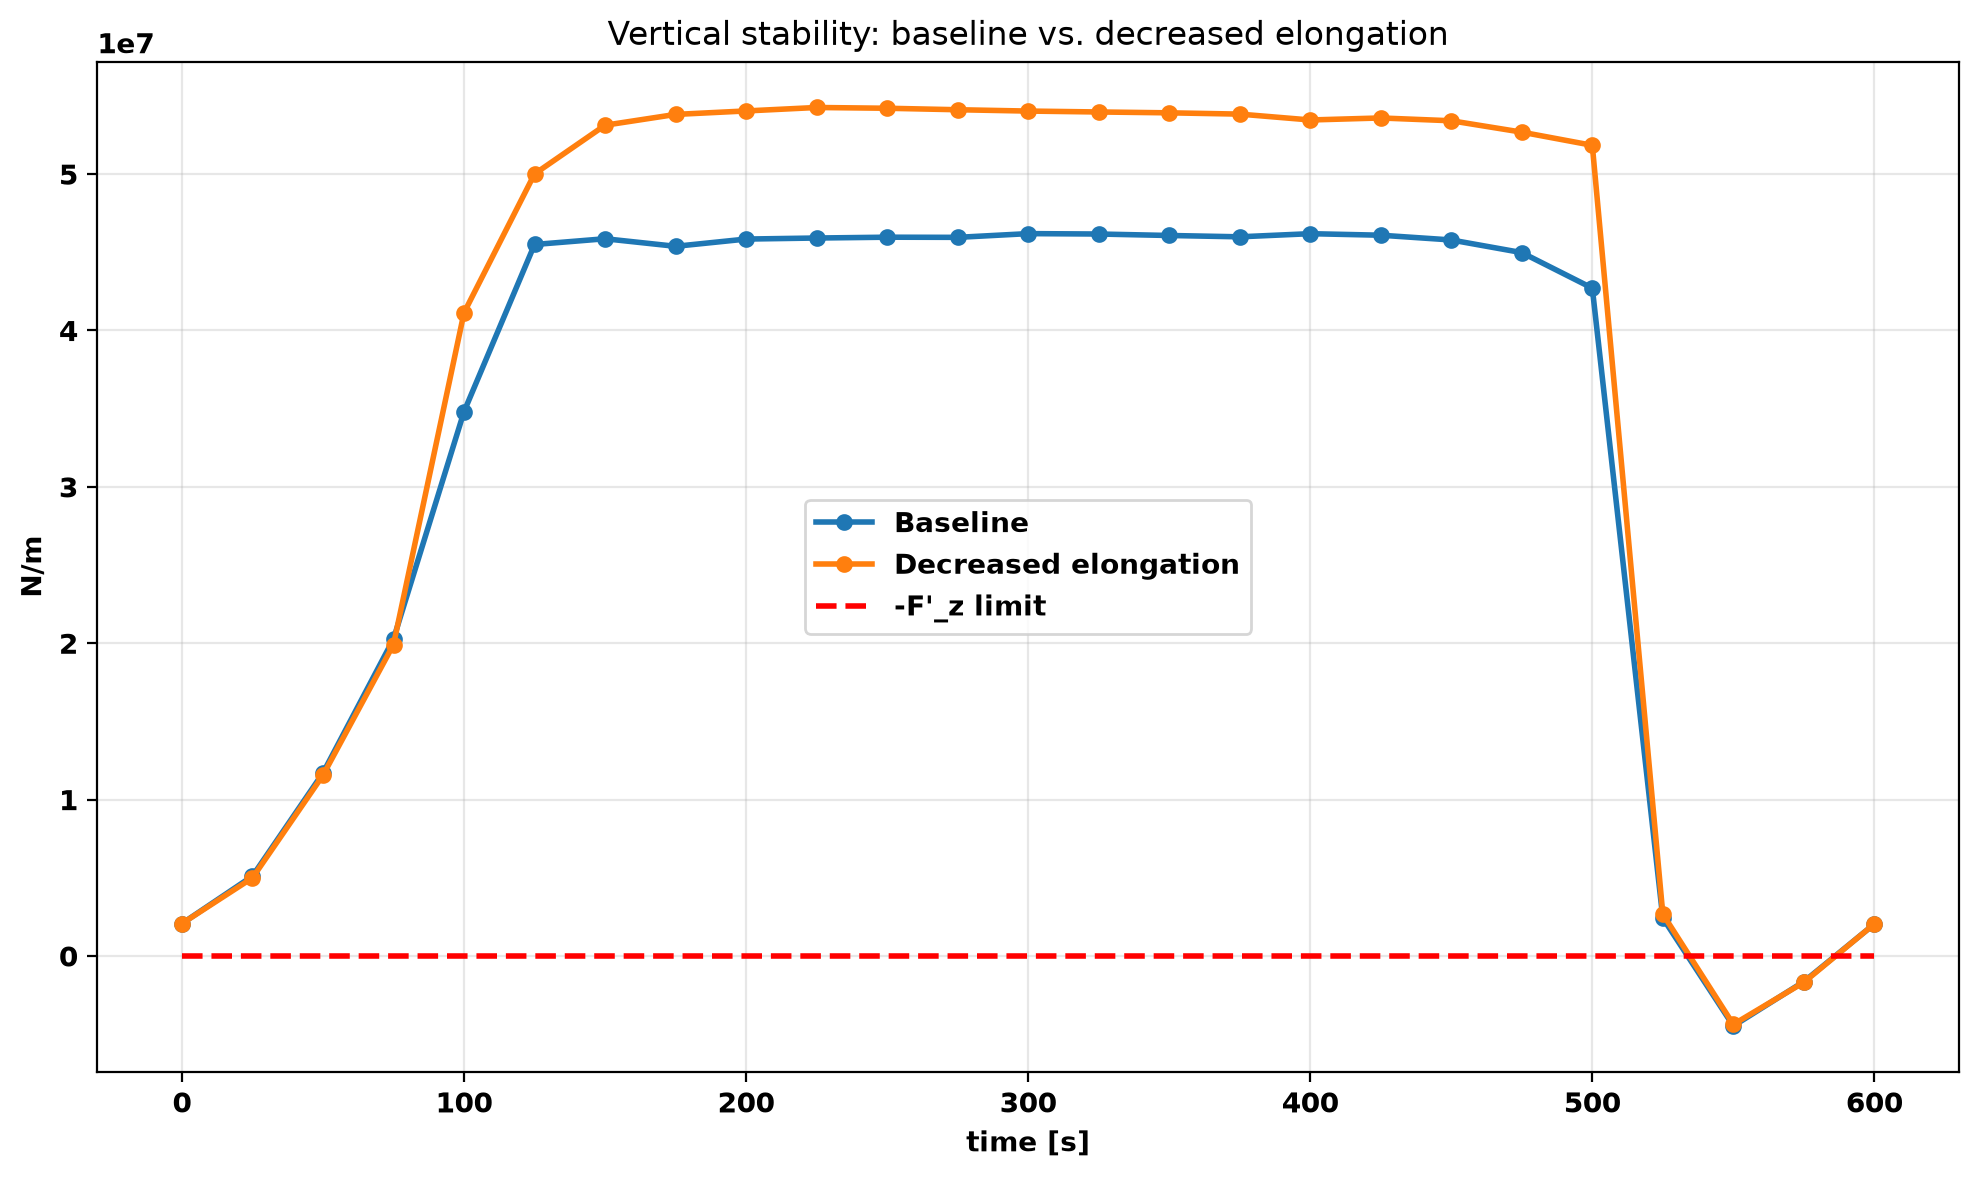

In [18]:
# Plot of baseline pulse with pulse perturbed via reduced elongation change
limits_pert = compute_disruptivity_limits(tmtx_kappa)
limits_base = compute_disruptivity_limits(tmtx)

fig, ax = plt.subplots(figsize=(10, 6))
for limits, label in [(limits_base, 'Baseline'), (limits_pert, 'Decreased elongation')]:
    entry = limits['all_limits_units']['vde']
    ax.plot(limits['tm_times'], entry['value'], 'o-', markersize=4, label=label)
ax.plot(limits_base['tm_times'], limits_base['all_limits_units']['vde']['limit_curve'], 'r--', label="-F'_z limit")
ax.set_xlabel('time [s]')
ax.set_ylabel(limits_base['all_limits_units']['vde']['units'])
ax.set_title("Vertical stability: baseline vs. decreased elongation")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

At t=100s, -F'_z rises from the baseline such that the margin is further from the instability threshold. Elongation is reduced with all other parameters held constant (except for x point and shape target variables which is necessary to accomplish the pulse design change), demonstrating the expected inverse relationship: reduced elongation increases vertical stability.

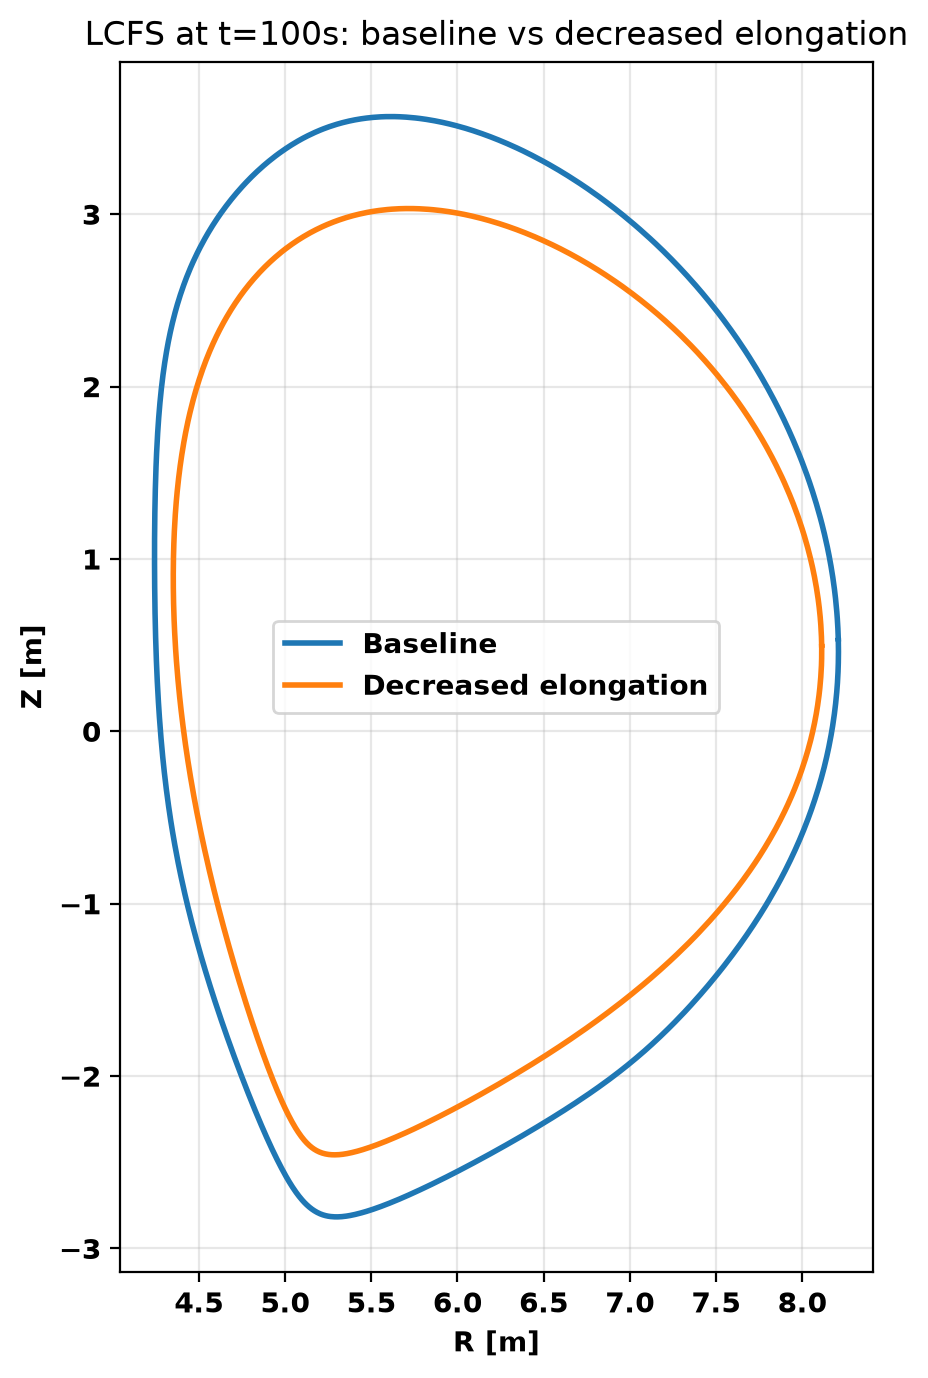

In [19]:
from OpenFUSIONToolkit.TokaMaker.pulse_design import _trace_lcfs_for_evolution_plot

# Compare LCFS shape at t=100s, between baseline and the elongation perturbation
i_lcfs = int(np.argmin(np.abs(np.array(tmtx._tm_times) - 100.0)))
lcfs_base = _trace_lcfs_for_evolution_plot(tmtx.state['equil'][i_lcfs])
lcfs_pert = _trace_lcfs_for_evolution_plot(tmtx_kappa.state['equil'][i_lcfs])

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(lcfs_base[:, 0], lcfs_base[:, 1], '-', color='tab:blue', label='Baseline')
ax.plot(lcfs_pert[:, 0], lcfs_pert[:, 1], '-', color='tab:orange', label='Decreased elongation')
ax.set_xlabel('R [m]')
ax.set_ylabel('Z [m]')
ax.set_title(f"LCFS at t={tmtx._tm_times[i_lcfs]:.0f}s: baseline vs decreased elongation")
ax.set_aspect('equal')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

We now compare `compute_vertical_stability_margin()` (Tobin's force-gradient margin, `-F'_z` [N/m]) and `compute_linear_stability()` (the pre-existing ARPACK eigenvalue growth rate, `gamma` [1/s]). 

During flattop the two metrics read differently: `-F'_z` shows the equilibrium as stable, while `gamma` stays persistently small and positive (~1-7/s). Both metrics agree, however, that the rampdown window around t=500-580s is the most vertically unstable part of the pulse.

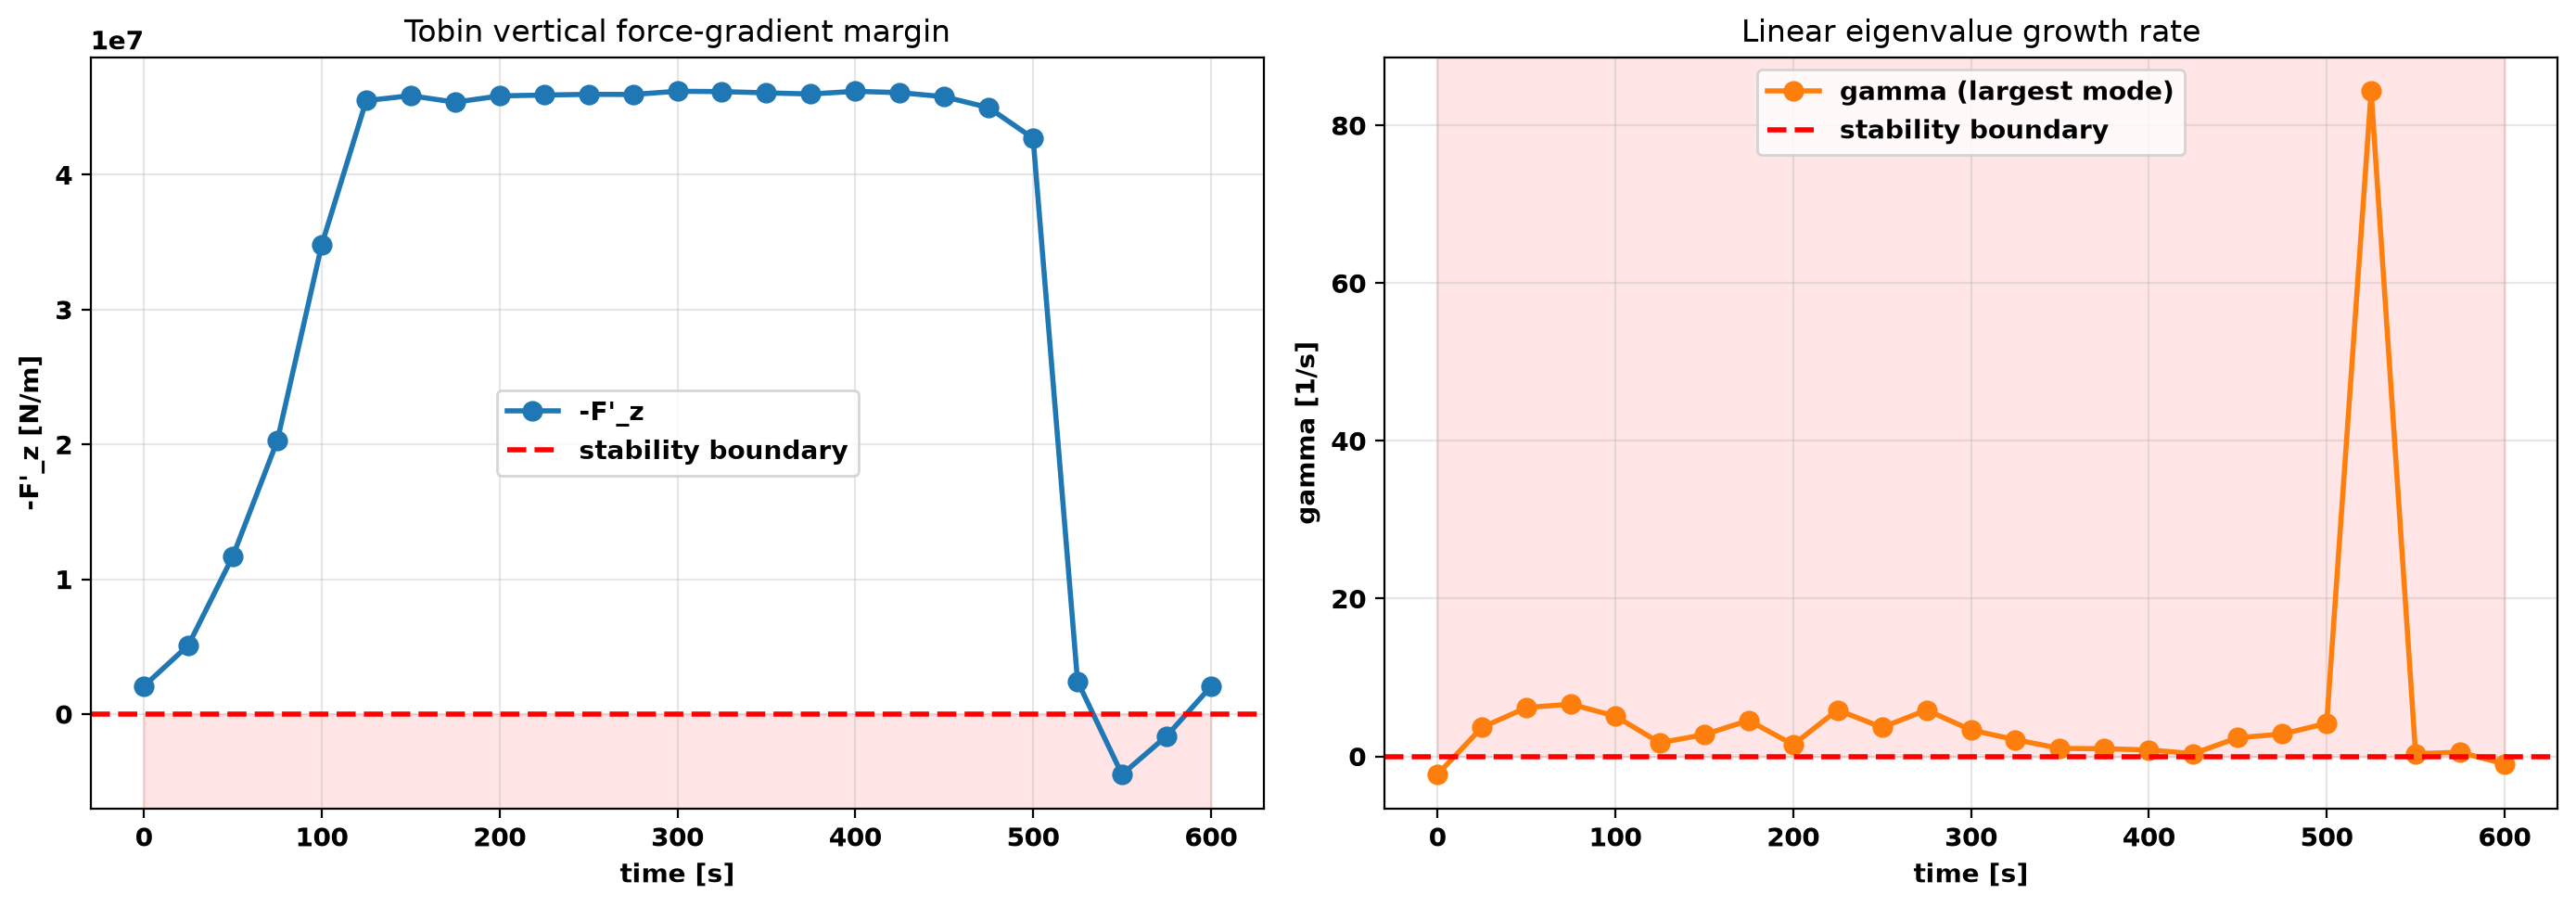

In [20]:
omega = 300.0
nmodes = 4
tm = np.asarray(tmtx._tm_times)

neg_Fz = np.array([tmtx.state['equil'][i].compute_vertical_stability_margin() for i in range(len(tm))])

gamma_max = np.zeros(len(tm))
for i in range(len(tm)):
    gammas, _ = tmtx.state['equil'][i].compute_linear_stability(nmodes=nmodes, omega=omega)
    gamma_max[i] = gammas.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(tm, neg_Fz, 'o-', color='tab:blue', label="-F'_z")
ax1.axhline(0.0, color='r', ls='--', label='stability boundary')
ylim1 = ax1.get_ylim()
ax1.fill_between([tm[0], tm[-1]], 0.0, ylim1[0], color='red', alpha=0.1)
ax1.set_ylim(ylim1)
ax1.set_xlabel('time [s]')
ax1.set_ylabel("-F'_z [N/m]")
ax1.set_title("Tobin vertical force-gradient margin")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(tm, gamma_max, 'o-', color='tab:orange', label='gamma (largest mode)')
ax2.axhline(0.0, color='r', ls='--', label='stability boundary')
ylim2 = ax2.get_ylim()
ax2.fill_between([tm[0], tm[-1]], 0.0, ylim2[1], color='red', alpha=0.1)
ax2.set_ylim(ylim2)
ax2.set_xlabel('time [s]')
ax2.set_ylabel('gamma [1/s]')
ax2.set_title('Linear eigenvalue growth rate')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()